In [1]:
!pip -q install awscli

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.


In [2]:
!mkdir -p /content/ds006072
!aws s3 cp --no-sign-request s3://openneuro.org/ds006072/session_data.csv /content/ds006072/

download: s3://openneuro.org/ds006072/session_data.csv to ds006072/session_data.csv


In [3]:
session_df = pd.read_csv("/content/ds006072/session_data.csv")
session_df.head()

,PatientName,SessionID,SessionNumber
0,P1,P1_Baseline1,sub-P1_ses-1
1,P1,P1_Baseline2,sub-P1_ses-2
2,P1,P1_Baseline3,sub-P1_ses-3
3,P1,P1_Baseline4,sub-P1_ses-4
4,P1,P1_Baseline5,sub-P1_ses-5


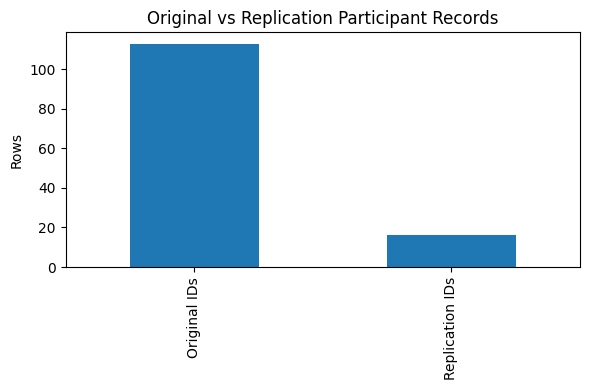

In [5]:
labels = session_df["PatientName"].str.endswith("R").map({
    True: "Replication IDs",
    False: "Original IDs"
})

group_counts = labels.value_counts()

plt.figure(figsize=(6,4))
group_counts.plot(kind="bar")
plt.title("Original vs Replication Participant Records")
plt.xlabel("")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

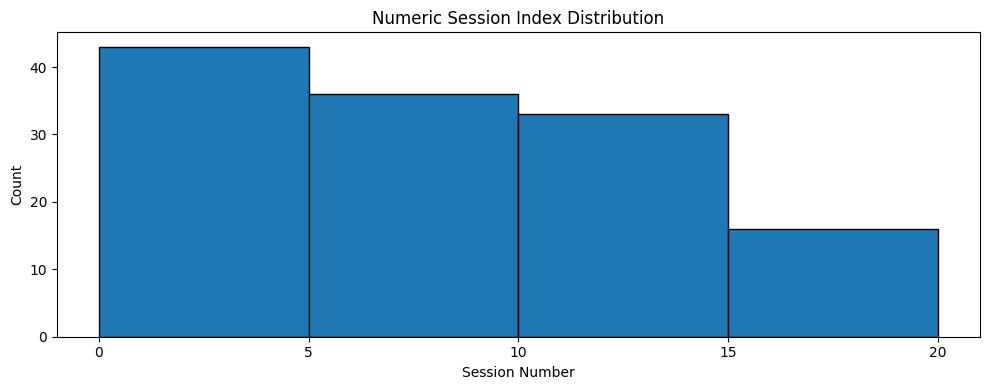

In [14]:
import re

session_nums = (
    session_df["SessionNumber"]
    .astype(str)
    .str.extract(r"ses-(\d+)")[0]
    .astype(int)
)

plt.figure(figsize=(10,4))

bins = range(0, session_nums.max() + 2, 5)

plt.hist(session_nums, bins=bins, edgecolor="black")

plt.title("Numeric Session Index Distribution")
plt.xlabel("Session Number")
plt.ylabel("Count")
plt.xticks(bins)
plt.tight_layout()
plt.show()

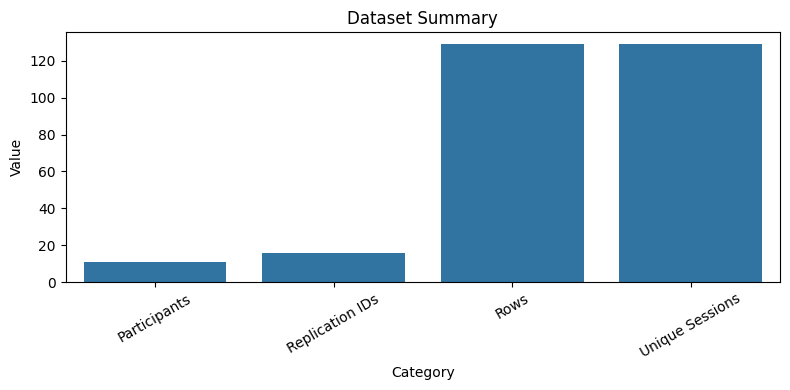

In [7]:
summary = pd.DataFrame({
    "Category": [
        "Participants",
        "Replication IDs",
        "Rows",
        "Unique Sessions"
    ],
    "Value": [
        session_df["PatientName"].nunique(),
        session_df["PatientName"].str.endswith("R").sum(),
        len(session_df),
        session_df["SessionID"].nunique()
    ]
})

plt.figure(figsize=(8,4))
sns.barplot(data=summary, x="Category", y="Value")
plt.title("Dataset Summary")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [9]:
print("Notebook 4 complete.")
print("Figures generated successfully.")

Notebook 4 complete.
Figures generated successfully.
